# Namazi RAG walkthrough

I wrote this notebook to go through the project one step at a time, the same way I checked it myself:
books, chunks, index, search, evaluation, answers, tests. Every step prints something, so you can see with your own eyes whether it works.

Run it from the project folder (the one with `README.md`). It needs the index in `data/index`, which you get from `python -m scripts.ingest`.
You don't need an LLM to run it: section 10 uses a fake one, and section 11 only reads answers I saved earlier.

## 1. Setup

In [1]:
import logging
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

from app.config import get_settings

settings = get_settings()
print("embedding model:", settings.embedding_model)
print("books folder   :", settings.books_dir)
print("top_k           :", settings.top_k)
print("weights dense:bm25 =", settings.weight_dense, ":", settings.weight_bm25)

embedding model: intfloat/multilingual-e5-base
books folder   : data/books
top_k           : 5
weights dense:bm25 = 2.0 : 1.0


## 2. Load the books
The loader reads every PDF page by page. If a book has almost no words, it is probably a scan with no text layer,
so I count the words per book to catch that.

In [2]:
from app.loader import load_books

books = load_books(settings.books_dir)
table = pd.DataFrame(
    [{"book": name, "pages": len(pages), "words": sum(len(text.split()) for _, text in pages)}
     for name, pages in books.items()]
)
print(len(books), "books,", table["pages"].sum(), "pages,", table["words"].sum(), "words")
table.sort_values("words", ascending=False).reset_index(drop=True)

20 books, 2512 pages, 1419941 words


,book,pages,words
0,KDIGO 2021 Glomerular Diseases,281,152927
1,KDIGO 2024 CKD Guideline,199,148858
2,KDIGO 2012 CKD Evaluation and Management,162,124303
3,KDIGO 2009 Kidney Transplant Recipient Care,168,109863
4,KDIGO 2012 Acute Kidney Injury,141,103930
5,KDIGO 2022 Diabetes in CKD,128,90001
6,WHO Clinical Management of COVID-19,181,85405
7,KDIGO 2020 Kidney Transplant Candidate,106,84102
8,KDIGO 2012 Blood Pressure in CKD,85,71112
9,KDIGO 2026 Anemia in CKD,99,64888


Here is one raw page. PDF text is messy: a sign like >= often comes out as some odd letter.
That will matter later, when I search for exact numbers.

In [3]:
pages = dict(books["KDIGO 2012 Acute Kidney Injury"])
print(pages[10][:600])

Foreword
Kidney International Supplements (2012) 2, 7; doi:10.1038/kisup.2012.8
It is our hope that this document will serve several useful
purposes. Our primary goal is to improve patient care. We
hope to accomplish this, in the short term, by helping
clinicians know and better understand the evidence (or lack
of evidence) that determines current practice. By providing
comprehensive evidence-based recommendations, this guide-
line will also help deﬁne areas where evidence is lacking and
research is needed. Helping to deﬁne a research agenda is an
often neglected, but very important, function 


## 3. Chunking
Each chunk is about 250 words and stops at the end of a sentence. The last sentences of a chunk are repeated at the start of the next one
(an overlap of 50 words), so a fact that sits on the border doesn't get cut in half.

In [4]:
from app.chunking import chunk_pages

name = "KDIGO 2012 Acute Kidney Injury"
chunks = chunk_pages(name, books[name], settings.chunk_size, settings.chunk_overlap)
lengths = [len(c.text.split()) for c in chunks]
print(len(chunks), "chunks | words per chunk: min", min(lengths), "max", max(lengths),
      "average", round(sum(lengths) / len(lengths)))
print()
print("end of chunk 40  :", "...", chunks[40].text[-200:])
print("start of chunk 41:", chunks[41].text[:200], "...")

523

 chunks | words per chunk: min 33 max 250 average 234

end of chunk 40  : ... e is no unifying approach to the diagnosis and care of these patients. There is a worldwide need to recognize, detect, and intervene to circumvent the need for dialysis and to improve outcomes of AKI.
start of chunk 41: Importantly, there is no unifying approach to the diagnosis and care of these patients. There is a worldwide need to recognize, detect, and intervene to circumvent the need for dialysis and to improve ...


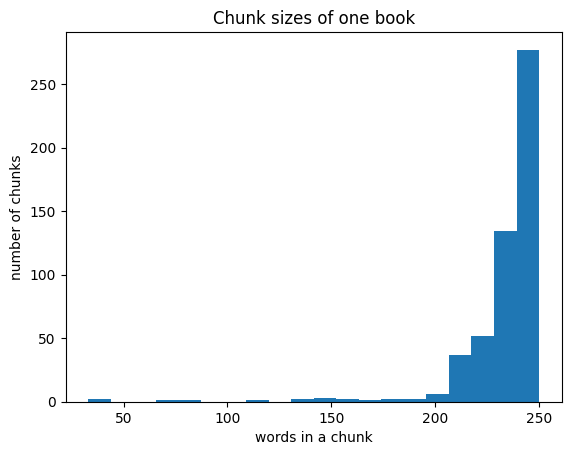

In [5]:
plt.hist(lengths, bins=20)
plt.xlabel("words in a chunk")
plt.ylabel("number of chunks")
plt.title("Chunk sizes of one book")
plt.show()

## 4. Load the index
I built the index earlier with `python -m scripts.ingest`. Loading it also builds the BM25 part in memory.

In [6]:
from app.embedder import make_embedder
from app.index import Index

embedder = make_embedder(settings)
index = Index.load(settings.index_dir, settings.embedding_model, settings.bm25_k1, settings.bm25_b)

print("chunks:", len(index), "| vector size:", index.meta["dim"], "| built at:", index.meta["created_at"])
chunks_per_book = pd.Series([c.book for c in index.chunks]).value_counts()
chunks_per_book

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7563.81it/s]

chunks: 7112 | vector size: 768 | built at: 2026-10-07 18:16:51


KDIGO 2021 Glomerular Diseases                 758
KDIGO 2024 CKD Guideline                       744
KDIGO 2012 CKD Evaluation and Management       620
KDIGO 2009 Kidney Transplant Recipient Care    540
KDIGO 2012 Acute Kidney Injury                 523
KDIGO 2022 Diabetes in CKD                     453
WHO Clinical Management of COVID-19            432
KDIGO 2020 Kidney Transplant Candidate         418
KDIGO 2012 Blood Pressure in CKD               353
KDIGO 2026 Anemia in CKD                       327
WHO Malaria Diagnostic Testing Manual          301
KDIGO 2018 Hepatitis C in CKD                  252
KDIGO 2012 Anemia in CKD                       230
WHO mhGAP Intervention Guide v2                219
WHO Systematic Screening for Tuberculosis      206
WHO Meningitis Guidelines                      198
KDIGO 2017 CKD Mineral and Bone Disorder       185
KDIGO 2013 Lipid Management in CKD             166
WHO Child Health Recommendations               105
GOLD COPD Pocket Guide 2024    

## 5. Search
I search the same question three ways: by meaning only (dense), by exact words only (BM25), and both together (hybrid).
The hybrid version merges the two lists with Reciprocal Rank Fusion.

In [7]:
from app.retriever import HybridRetriever, RetrievalParams


def make_retriever(weight_dense, weight_bm25, top_k=5, rrf_k=None):
    params = RetrievalParams(top_k, settings.oversample, rrf_k or settings.rrf_k, weight_dense, weight_bm25)
    return HybridRetriever(index, embedder, params)


modes = [("dense only", 1, 0), ("BM25 only", 0, 1), ("hybrid 1:1", 1, 1), ("hybrid 2:1", 2, 1)]
question = "When should the metformin dose be reduced in CKD?"
print("Question:", question)
for mode_name, w_dense, w_bm25 in modes:
    print("\n" + mode_name)
    for hit in make_retriever(w_dense, w_bm25).search(question):
        print(f"  {hit.score:.4f}  {hit.chunk.book}, page {hit.chunk.page}")

Question: When should the metformin dose be reduced in CKD?

dense only


  0.0164  KDIGO 2022 Diabetes in CKD, page 81
  0.0161  KDIGO 2012 CKD Evaluation and Management, page 114
  0.0159  KDIGO 2022 Diabetes in CKD, page 80
  0.0156  KDIGO 2022 Diabetes in CKD, page 78
  0.0154  KDIGO 2012 CKD Evaluation and Management, page 25

BM25 only
  0.0164  KDIGO 2022 Diabetes in CKD, page 80
  0.0161  KDIGO 2022 Diabetes in CKD, page 80
  0.0159  KDIGO 2022 Diabetes in CKD, page 27
  0.0156  KDIGO 2022 Diabetes in CKD, page 125
  0.0154  KDIGO 2022 Diabetes in CKD, page 82

hybrid 1:1
  0.0323  KDIGO 2022 Diabetes in CKD, page 80
  0.0311  KDIGO 2022 Diabetes in CKD, page 80
  0.0306  KDIGO 2022 Diabetes in CKD, page 27
  0.0291  KDIGO 2022 Diabetes in CKD, page 78
  0.0289  KDIGO 2022 Diabetes in CKD, page 81

hybrid 2:1
  0.0481  KDIGO 2022 Diabetes in CKD, page 80
  0.0460  KDIGO 2022 Diabetes in CKD, page 80
  0.0453  KDIGO 2022 Diabetes in CKD, page 27
  0.0448  KDIGO 2022 Diabetes in CKD, page 78
  0.0440  KDIGO 2022 Diabetes in CKD, page 81


This is how the merge works. Each search gives a ranking. A chunk earns `weight / (k + rank)` points from each ranking, and the points add up.
Only the ranks are used, so the two score scales never have to match.
Here is a tiny example with made-up chunk numbers:

In [8]:
from app.retriever import rrf_fuse

dense_ranking = [1, 2, 3]   # chunk numbers, best first
bm25_ranking = [3, 1, 4]
print(rrf_fuse([dense_ranking, bm25_ranking], [1, 1], k=60))

[(1, 0.03252247488101534), (3, 0.032266458495966696), (2, 0.016129032258064516), (4, 0.015873015873015872)]


Chunks 1 and 3 are in both lists, so they end up on top. Chunks 2 and 4 are only in one list.

## 6. Evaluation
`data/eval/eval_questions.jsonl` has 141 questions: 76 English and 65 Persian. For each one I wrote a short phrase that has to appear in the right chunk.
Hit rate asks "is the right chunk in the top 5?" and MRR asks "how high did it rank?".
34 of the questions can't be answered from the books at all (their evidence is null). 36 of the Persian questions are the Persian version of an English one,
so the same fact can be compared in both languages.
I split the questions 70/30 into a dev part and a test part with a fixed seed, exactly like `scripts/tune.py` does.

In [9]:
from scripts.tune import evaluate, load_eval, split_eval

items = load_eval("data/eval/eval_questions.jsonl")
dev, test = split_eval(items, 42)
print(len(items), "questions:", len(dev), "dev,", len(test), "test")

rows = []
for mode_name, w_dense, w_bm25 in modes:
    retriever = make_retriever(w_dense, w_bm25)
    for part_name, part in [("dev", dev), ("test", test), ("all", items)]:
        result = evaluate(retriever, part, 5)
        rows.append({"mode": mode_name, "questions": part_name, "n": result["n"],
                     "hit_rate@5": round(result["hit_rate"], 3), "mrr": round(result["mrr"], 3)})
results = pd.DataFrame(rows)
results.pivot(index="mode", columns="questions", values=["hit_rate@5", "mrr"])

141 questions: 98 dev, 43 test


hit_rate@5                  mrr              
questions         all    dev   test    all    dev   test
mode                                                    
BM25 only       0.449  0.467  0.406  0.332  0.347  0.297
dense only      0.533  0.547  0.500  0.350  0.392  0.251
hybrid 1:1      0.607  0.600  0.625  0.421  0.456  0.340
hybrid 2:1      0.607  0.613  0.594  0.424  0.465  0.329

The test part has very few answerable questions, so its numbers jump around.
I show the "all" columns too, but remember that I picked the settings on the dev part only.

## 7. The settings I tried
`python -m scripts.tune` tried 33 settings: 3 chunk sizes, 5 dense/BM25 mixes and 3 RRF constants.
Below is the table it saved.

In [10]:
tuning = pd.read_csv("docs/tuning_results.csv")
print(len(tuning), "settings tried")
tuning.head(10)

33 settings tried


,chunk_size,overlap,weight_dense,weight_bm25,rrf_k,n_chunks,dev_hit_rate,dev_mrr
0,250,50,2,1,60,7112,0.6133,0.4647
1,250,50,2,1,20,7112,0.6133,0.4647
2,250,50,2,1,100,7112,0.6133,0.4647
3,150,30,2,1,20,11891,0.6000,0.4609
4,250,50,1,1,20,7112,0.6000,0.4562
5,250,50,1,1,60,7112,0.6000,0.4556
6,250,50,1,1,100,7112,0.6000,0.4556
7,150,30,2,1,60,11891,0.6000,0.4542
8,150,30,2,1,100,11891,0.6000,0.4542
9,150,30,1,1,60,11891,0.6000,0.4504


best MRR per chunk size:
             dev_hit_rate  dev_mrr
chunk_size                       
150               0.6000   0.4609
250               0.6133   0.4647
400               0.5600   0.4498 

best MRR per dense:bm25 mix:
 weight_dense  weight_bm25
0             1              0.3931
1             0              0.4287
              1              0.4562
              2              0.4498
2             1              0.4647
Name: dev_mrr, dtype: float64 

best MRR per rrf_k:
 rrf_k
20     0.4647
60     0.4647
100    0.4647
Name: dev_mrr, dtype: float64


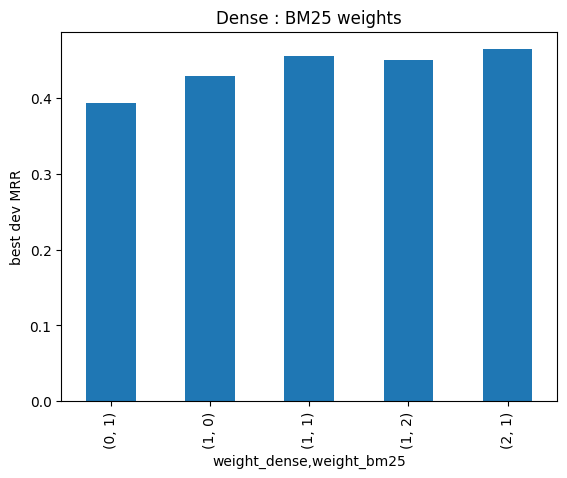

In [11]:
by_chunk = tuning.groupby("chunk_size")[["dev_hit_rate", "dev_mrr"]].max()
by_mix = tuning.groupby(["weight_dense", "weight_bm25"])["dev_mrr"].max()
by_rrf = tuning.groupby("rrf_k")["dev_mrr"].max()
print("best MRR per chunk size:\n", by_chunk, "\n")
print("best MRR per dense:bm25 mix:\n", by_mix, "\n")
print("best MRR per rrf_k:\n", by_rrf)

by_mix.plot(kind="bar")
plt.ylabel("best dev MRR")
plt.title("Dense : BM25 weights")
plt.show()

## 8. Where does it fail?
For every answerable question I look at where the right chunk lands in the top 30.
"NaN" means it isn't in the top 30 at all.

In [12]:
from scripts.tune import norm

retriever = make_retriever(settings.weight_dense, settings.weight_bm25, top_k=30)
rows = []
for item in items:
    if not item["evidence"]:
        continue
    hits = retriever.search(item["question"], 30)
    rank = next((n for n, hit in enumerate(hits, 1) if norm(item["evidence"]) in norm(hit.chunk.text)), None)
    rows.append({"question": item["question"][:60], "persian": not item["question"].isascii(), "rank": rank})
ranks = pd.DataFrame(rows)

english = ranks[~ranks["persian"]]
persian = ranks[ranks["persian"]]
print("English: in top 5 ->", (english["rank"] <= 5).sum(), "of", len(english))
print("Persian: in top 5 ->", (persian["rank"] <= 5).sum(), "of", len(persian))
ranks[ranks["rank"].isna() | (ranks["rank"] > 1)]

English: in top 5 -> 50 of 58
Persian: in top 5 -> 15 of 49


,question,persian,rank
0,How is acute kidney injury defined?,False,5.0
1,At what haemoglobin level is anaemia diagnosed...,False,9.0
3,Which corticosteroid is preferred in bacterial...,False,4.0
4,How is chronic kidney disease defined?,False,2.0
5,Should patients with type 2 diabetes and CKD r...,False,2.0
...,...,...,...
101,آسیب حاد کلیه چگونه تعریف می‌شود؟,True,NaN
102,بیماری انسدادی مزمن ریه چگونه تشخیص داده می‌شود؟,True,NaN
104,درمان با ESA در بیماران دیالیزی کم‌خون چه زمان...,True,15.0
105,نوزادان تا چه مدت باید فقط با شیر مادر تغذیه ش...,True,21.0


Here the Persian question goes into the search exactly as it was typed, and only 15 of 49 find the right passage (English: 50 of 58).
The real app first asks the LLM to translate the question into English. With that step, 40 of 49 Persian questions get the right passage into the sources (see section 11).
Persian is still the weakest part of the system.

## 9. Can we tell when the books have no answer?
`MIN_DENSE_SCORE` would skip the LLM whenever the best similarity is low. To see if that could work,
I compare the best similarity of the answerable and the unanswerable questions.

            count    min      mean    max
answerable                               
False        34.0  0.773  0.808471  0.851
True        107.0  0.748  0.851028  0.918


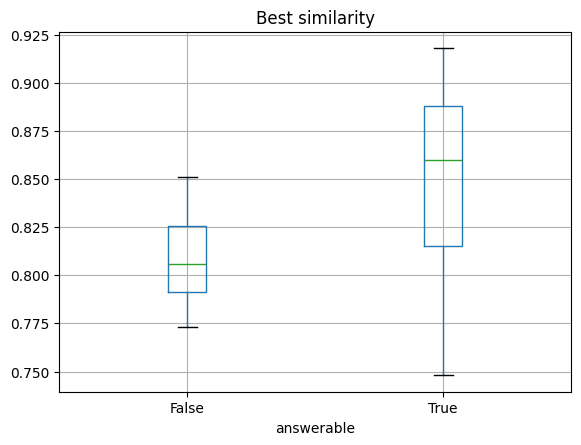

In [13]:
retriever = make_retriever(settings.weight_dense, settings.weight_bm25, top_k=5)
rows = []
for item in items:
    best = max(hit.dense_score for hit in retriever.search(item["question"], 5))
    rows.append({"answerable": bool(item["evidence"]), "best_similarity": round(best, 3)})
scores = pd.DataFrame(rows)
print(scores.groupby("answerable")["best_similarity"].describe()[["count", "min", "mean", "max"]])

scores.boxplot(column="best_similarity", by="answerable")
plt.suptitle("")
plt.title("Best similarity")
plt.show()

The two groups overlap. Answerable questions go as low as 0.748 and unanswerable ones as high as 0.851,
so a cutoff would either block real questions or let unanswerable ones through. That is why I left `MIN_DENSE_SCORE` at 0
and let the `NO_ANSWER` rule in the prompt decide. (This table uses the Persian questions untranslated, so a few Persian scores
are lower than they are in the real app.)

## 10. The answer step (with a fake LLM)
You don't need an API key here. The fake LLM just returns whatever text I give it, so I can see the prompt that would be sent
and how the app handles the reply. The log lines show what happens inside.

In [14]:
from app.llm import LLMResult
from app.rag import RagService


class FakeLLM:
    def __init__(self, reply):
        self.reply = reply
        self.last_prompt = ""

    def complete(self, system, user):
        self.last_prompt = user
        return LLMResult(self.reply, prompt_tokens=1500, completion_tokens=40)


logging.basicConfig(level=logging.INFO, format="%(name)s: %(message)s", force=True)
for noisy in ("httpx", "sentence_transformers", "urllib3", "filelock"):
    logging.getLogger(noisy).setLevel(logging.WARNING)

llm = FakeLLM("Dexamethasone is the preferred corticosteroid [1].")
rag = RagService(make_retriever(settings.weight_dense, settings.weight_bm25), llm)

answer = rag.ask("Which corticosteroid is preferred in bacterial meningitis?")
print("\nanswered:", answer.answered)
print("answer  :", answer.answer)
for number, hit in enumerate(answer.sources, 1):
    print(f"  [{number}] {hit.chunk.book}, page {hit.chunk.page}")
print("\nstart of the prompt sent to the LLM:\n", llm.last_prompt[:400])

app.rag: search found 5 chunks, best similarity 0.882


app.rag: sending 5 sources (8894 characters) to the LLM


app.rag: answered with 5 sources



answered: True
answer  : Dexamethasone is the preferred corticosteroid [1].
  [1] WHO Meningitis Guidelines, page 76
  [2] WHO Meningitis Guidelines, page 74
  [3] WHO Meningitis Guidelines, page 75
  [4] WHO Meningitis Guidelines, page 22
  [5] WHO Meningitis Guidelines, page 23

start of the prompt sent to the LLM:
 SOURCES:
[1] (WHO Meningitis Guidelines, page 76)
The above recommendations on the use of corticosteroids as adjunctive treatment for suspected acute bacterial meningitis also apply to people living with HIV who are on antiretroviral therapy and have undetectable viral load (less than 50 copies/μl). Intravenous corticosteroids administered as adjunctive treatment for suspected acute bacterial meni


In [15]:
# the model says it cannot answer, even with an extra sentence after NO_ANSWER
llm.reply = "NO_ANSWER. The sources do not mention this."
answer = rag.ask("What is the target INR for a patient on warfarin?")
print("\nanswered:", answer.answered)
print("answer  :", answer.answer)

app.rag: search found 5 chunks, best similarity 0.865


app.rag: sending 5 sources (8024 characters) to the LLM


app.rag: the LLM found no answer in the sources



answered: False
answer  : I could not find the answer to this question in the hospital's reference books. پاسخ این پرسش در منابع موجود پیدا نشد.


To try a real LLM, put the `LLM_*` settings in `.env` and start the API with `uvicorn app.main:app_factory --factory`.
Then call `POST /v1/ask` like the README shows.

## 11. Answer check with a real LLM
I ran all 141 questions through the whole pipeline with `python -m scripts.check_answers --judge`, using a real local model
(`qwen2.5:32b-instruct` in Ollama, context 8192). The answers are saved in `docs/answer_check.csv`.
This is not the fake LLM from section 10. These are saved results, so the notebook itself doesn't need the LLM.

In [16]:
check = pd.read_csv("docs/answer_check.csv")
check["language"] = ["English" if q.isascii() else "Persian" for q in check["question"]]

rows = []
for language, part in check.groupby("language"):
    good = part[part["answerable"]]
    bad = part[~part["answerable"]]
    rows.append({
        "language": language,
        "answerable questions": len(good),
        "gave an answer": int(good["answered"].sum()),
        "has a citation": int(good["has_citation"].sum()),
        "right passage in sources": int(good["evidence_in_sources"].sum()),
        "right passage cited": int(good["evidence_cited"].sum()),
        "unanswerable questions": len(bad),
        "correctly said not found": int((~bad["answered"]).sum()),
        "seconds per question": round(part["seconds"].mean(), 1),
    })
pd.DataFrame(rows).set_index("language").T

language,English,Persian
answerable questions,58.0,49.0
gave an answer,57.0,41.0
has a citation,57.0,41.0
right passage in sources,50.0,40.0
right passage cited,46.0,34.0
unanswerable questions,18.0,16.0
correctly said not found,18.0,14.0
seconds per question,3.1,4.5


The worst mistake is answering a question the books can't answer. These are the cases:

In [17]:
wrong = check[(~check["answerable"]) & check["answered"]]
print(len(wrong), "unanswerable question(s) still got an answer\n")
for _, row in wrong.iterrows():
    print(row["question"])
    print(row["answer"][:400])

2 unanswerable question(s) still got an answer

اگزما در کودکان چگونه درمان می‌شود؟
درمان اگزما در کودکان شامل درمان‌های علائمی برای مدت زمان علائم مداوم است و می‌تواند شامل موارد زیر باشد:
- داروهای ضد هیستامینی خوراکی؛ اگر پاسخ مناسبی نداشته باشند، می‌توان داروهای کورتیکوئید توپیکال (کلاس ۳، ۴، ۵ یا ۶، مانند بتمتاپروئات) اضافه کرد؛ اگر پاسخ مناسبی نداشته باشند، می‌توان داروهای خوراکی ایترکونازول اضافه کرد؛ اگر پاسخ مناسبی نداشته باشند، می‌توان کرم پرمثرین ۵٪ (به کار گرفته شده ب
کمک‌های اولیه برای مارگزیدگی چیست؟
کمک‌های اولیه برای مارگزیدگی شامل داروهای ضد الهی مثل آدrenaline (به صورت تزریق مuskulosketāل)، اکسیژن به سرعت بالای 15 لیتر در دقیقه از طریق ماسک واریکاژ، تزریق 1 لیتر محلول کریستالوئید، داروهای مهارکننده H1 و کورتیکوئیدهاست [3].


Both made-up answers are in Persian. The eczema answer is built from a passage about permethrin cream (a scabies treatment) in the child-health book.
The snake bite answer lists oxygen, adrenaline and fluid amounts taken from texts about other things, and it has broken words in it.
Persian answers can also contain broken words in good answers (see the meningitis example in the README), so a Persian answer should always be read
with the English source next to it.

In [18]:
missed = check[check["answerable"] & ~check["evidence_cited"]].copy()
print(len(missed), "answerable questions where the right passage was not cited\n")
missed["question"] = missed["question"].str[:75]
missed[["question", "evidence_in_sources", "answered"]].reset_index(drop=True)

27 answerable questions where the right passage was not cited



,question,evidence_in_sources,answered
0,How is acute kidney injury defined?,False,True
1,How is chronic kidney disease defined?,False,True
2,Should all patients with CKD be screened for h...,False,True
3,Which immunosuppressive drugs are used for mai...,False,True
4,تعریف بیماری مزمن کلیه چیست؟,False,True
5,Is routine follow-up measurement of lipid leve...,True,False
6,Should children with newly identified CKD have...,True,True
7,Which prophylaxis should be considered in pati...,False,True
8,What three things does the CGA classification ...,True,True
9,How should blood films be prepared for malaria...,True,True


Whenever the right passage was in the sources but not cited, the model cited another passage that says almost the same thing.
A doctor has to read these rows and decide whether the answer is still right.
Also, two runs with the same settings don't give identical answers (70 of 93 were the same, and the number of right citations moved by 1),
so a difference of one or two questions means nothing.

## 12. Speed and answer quality in a few plots
Everything here comes from the real model run in section 11 (`docs/answer_check.csv`, one question at a time) and the load tests (`docs/load_test_results.csv`). The only thing measured live in this notebook is the search time.

### Search alone
How long does the search take before the LLM is even asked? (embedding the question + dense + BM25 + merge)

In [19]:
import time

retriever = make_retriever(settings.weight_dense, settings.weight_bm25)
english_questions = [item["question"] for item in items if item["question"].isascii()]

retriever.search(english_questions[0])  # the first call is slower, so warm up
search_ms = []
for question in english_questions:
    start = time.perf_counter()
    retriever.search(question)
    search_ms.append((time.perf_counter() - start) * 1000)

search_ms = pd.Series(search_ms)
print(f"{len(search_ms)} questions: median {search_ms.median():.0f} ms, 95% under {search_ms.quantile(0.95):.0f} ms, slowest {search_ms.max():.0f} ms")

76 questions: median 22 ms, 95% under 29 ms, slowest 31 ms


### Full answer time with the real model (one question at a time)

          count  mean  50%   max
language                        
English    76.0   3.1  2.8  14.0
Persian    65.0   4.5  4.0  10.9


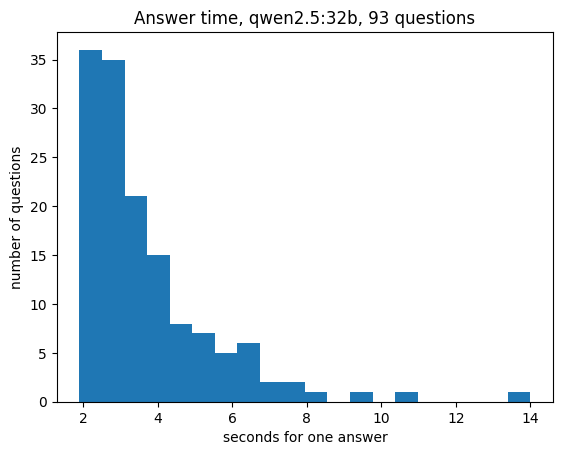

In [20]:
print(check.groupby("language")["seconds"].describe()[["count", "mean", "50%", "max"]].round(1))

plt.hist(check["seconds"], bins=20)
plt.xlabel("seconds for one answer")
plt.ylabel("number of questions")
plt.title("Answer time, qwen2.5:32b, 93 questions")
plt.show()

The one very slow answer is the first question, when Ollama had to load the model into the GPU. The Persian questions take longer because the LLM translates them first, which is a second LLM call.

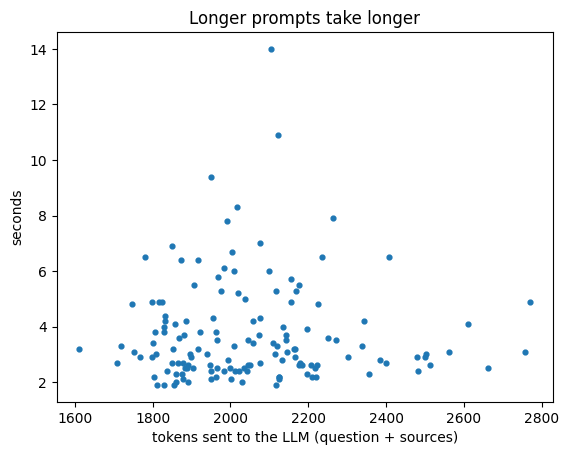

In [21]:
plt.scatter(check["prompt_tokens"], check["seconds"], s=12)
plt.xlabel("tokens sent to the LLM (question + sources)")
plt.ylabel("seconds")
plt.title("Longer prompts take longer")
plt.show()

### Where does the time go?

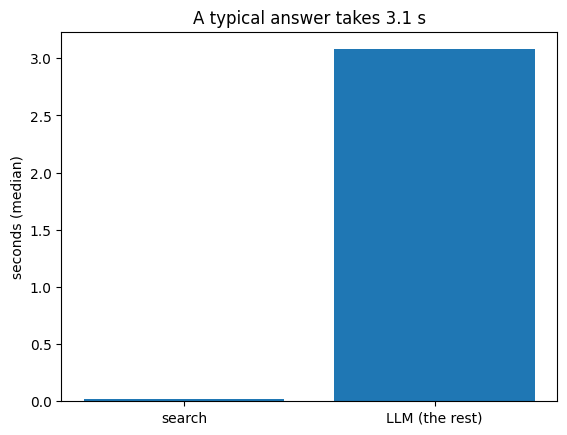

In [22]:
typical = check["seconds"].median()
plt.bar(["search", "LLM (the rest)"], [search_ms.median() / 1000, typical - search_ms.median() / 1000])
plt.ylabel("seconds (median)")
plt.title(f"A typical answer takes {typical:.1f} s")
plt.show()

The search is a small part of the wait. Almost all of the time is the LLM, so a faster GPU or a smaller model is the way to speed things up.

### Many users at once (load tests)

                                       users  concurrency  answered  \
test                                                                  
fake LLM (app only)                    10000          100     10000   
real model (qwen2.5:32b)                 400            8       400   
fake LLM, 10 at once                    2000           10      2000   
fake LLM, 50 at once                    2000           50      2000   
fake LLM, 100 at once                   2000          100      2000   
fake LLM, 200 at once                   2000          200      1995   
fake LLM, 500 at once                   2000          500      1991   
fake LLM, 1000 at once                  2000         1000      1999   
real model (qwen2.5:32b), 32 at once     128           32       128   
real model (qwen2.5:32b), 128 at once    256          128       256   

                                       questions_per_second  median_s   p95_s  \
test                                                              

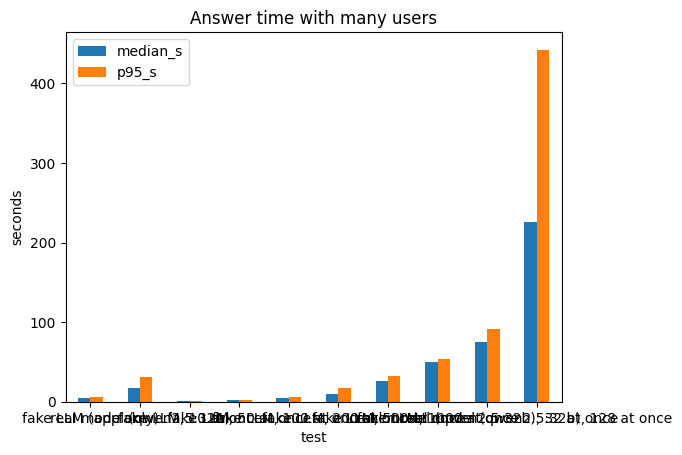

In [23]:
load = pd.read_csv("docs/load_test_results.csv").set_index("test")
print(load[["users", "concurrency", "answered", "questions_per_second", "median_s", "p95_s", "p99_s"]])

load[["median_s", "p95_s"]].plot(kind="bar", rot=0)
plt.ylabel("seconds")
plt.title("Answer time with many users")
plt.show()

With the fake LLM the app answered 10,000 users with no error. With the real model 400 of 400 were answered but each answer waited much longer, because one GPU can only answer about 0.4 questions per second. This is the real limit.

### How good are the answers?

          right passage in the sources  right passage cited  \
language                                                      
English                           86.0                 79.0   
Persian                           82.0                 69.0   

          unanswerable refused  
language                        
English                  100.0  
Persian                   88.0  


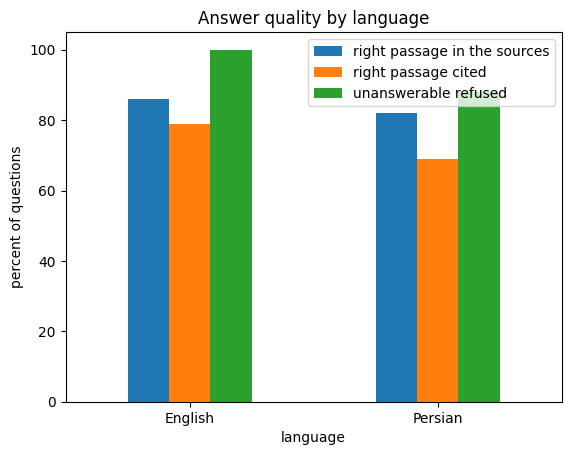

In [24]:
rows = []
for language, part in check.groupby("language"):
    good = part[part["answerable"]]
    bad = part[~part["answerable"]]
    rows.append({
        "language": language,
        "right passage in the sources": 100 * good["evidence_in_sources"].mean(),
        "right passage cited": 100 * good["evidence_cited"].mean(),
        "unanswerable refused": 100 * (~bad["answered"]).mean(),
    })
quality = pd.DataFrame(rows).set_index("language").round(0)
print(quality)

quality.plot(kind="bar", rot=0)
plt.ylabel("percent of questions")
plt.ylim(0, 105)
plt.title("Answer quality by language")
plt.show()

English is solid. Persian now has 49 answerable and 16 unanswerable questions, so one question moves a bar by only 2 to 6 points.
For Persian the right passage reached the LLM for 82% of the questions and was cited for 69%, and 14 of 16 unanswerable questions were refused.
It is clearly weaker than English, but not hopeless.

## 13. Search quality at k (hit rate, MRR, nDCG)
These are the usual numbers for the search part of a RAG system. Every question has one right passage, so recall@k is the same as hit@k.
(Precision@5 would be at most 0.2 here, so it says nothing useful.) I use the ranks from section 8; the Persian questions are searched as typed, without the translation step.

In [25]:
import numpy as np

def search_numbers(part):
    got = part["rank"].fillna(999)  # 999 = not in the top 30
    numbers = {f"hit@{k}": (got <= k).mean() for k in (1, 3, 5, 10)}
    numbers["MRR"] = (1 / got).mean()
    numbers["nDCG@10"] = np.where(got <= 10, 1 / np.log2(got + 1), 0).mean()
    return numbers

search_table = pd.DataFrame({
    f"English ({len(english)})": search_numbers(english),
    f"Persian, not translated ({len(persian)})": search_numbers(persian),
}).T.round(3)
search_table

,hit@1,hit@3,hit@5,hit@10,MRR,nDCG@10
English (58),0.500,0.724,0.862,0.914,0.640,0.704
"Persian, not translated (49)",0.122,0.184,0.306,0.388,0.196,0.234


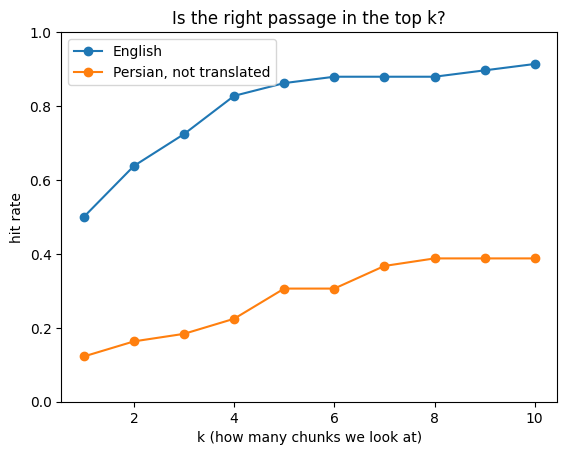

In [26]:
for name, part in [("English", english), ("Persian, not translated", persian)]:
    got = part["rank"].fillna(999)
    plt.plot(range(1, 11), [(got <= k).mean() for k in range(1, 11)], marker="o", label=name)
plt.xlabel("k (how many chunks we look at)")
plt.ylabel("hit rate")
plt.ylim(0, 1)
plt.legend()
plt.title("Is the right passage in the top k?")
plt.show()

In [27]:
persian_checked = check[(check["language"] == "Persian") & check["answerable"]]
print(f"Persian with the translation step: the right passage reached the LLM for "
      f"{persian_checked['evidence_in_sources'].sum()} of {len(persian_checked)} questions")

Persian with the translation step: the right passage reached the LLM for 40 of 49 questions


## 14. Hallucination measures
A made-up answer can look like three different things, so I count each one:
- **Answering when the books have nothing** (34 questions). This is the main number: the model should say "not found".
- **A number in the answer that is in no source.** A wrong dose is the worst case.
- **A citation like [7] when there are only 5 sources.**
- **An LLM judge** that reads the sources and the answer and says SUPPORTED or NOT_SUPPORTED. It is the same model as the answerer, so it can be too kind. I checked it with made-up wrong answers (it caught them), but treat it as a rough signal.

In [28]:
rows = []
for language, part in check.groupby("language"):
    unanswerable = part[~part["answerable"]]
    answered = part[part["answered"]]
    rows.append({
        "language": language,
        "unanswerable questions": len(unanswerable),
        "...that still got an answer": int(unanswerable["answered"].sum()),
        "answers given": len(answered),
        "number in no source": int((answered["made_up_numbers"] > 0).sum()),
        "citation that does not exist": int(answered["bad_citation"].sum()),
        "judge: not backed by the sources": int(answered["judge_supported"].eq(False).sum()),
    })
hallucination = pd.DataFrame(rows).set_index("language")
hallucination.T

language,English,Persian
unanswerable questions,18,16
...that still got an answer,0,2
answers given,57,43
number in no source,0,0
citation that does not exist,0,0
judge: not backed by the sources,0,0


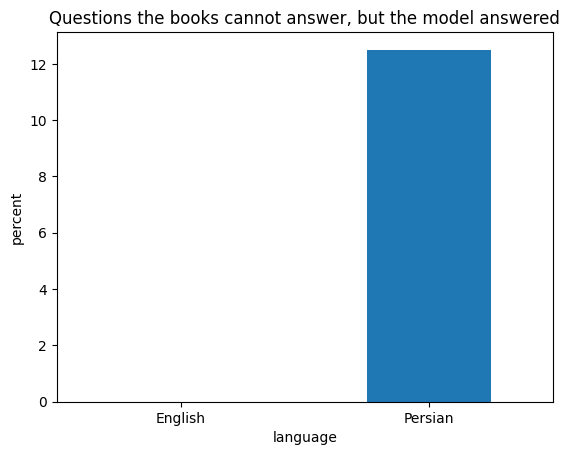


اگزما در کودکان چگونه درمان می‌شود؟
درمان اگزما در کودکان شامل درمان‌های علائمی برای مدت زمان علائم مداوم است و می‌تواند شامل موارد زیر باشد:
- داروهای ضد هیستامینی خوراکی؛ اگر پاسخ مناسبی نداشته باشند، می‌توان داروهای کورتیکوئید توپیکال (کلاس ۳، ۴، ۵ یا ۶، مانند بتمتاپروئات) اضافه کرد؛ اگر پاسخ مناسبی نداشته باشند، می‌توان داروهای خو

کمک‌های اولیه برای مارگزیدگی چیست؟
کمک‌های اولیه برای مارگزیدگی شامل داروهای ضد الهی مثل آدrenaline (به صورت تزریق مuskulosketāل)، اکسیژن به سرعت بالای 15 لیتر در دقیقه از طریق ماسک واریکاژ، تزریق 1 لیتر محلول کریستالوئید، داروهای مهارکننده H1 و کورتیکوئیدهاست [3].


In [29]:
share = 100 * hallucination["...that still got an answer"] / hallucination["unanswerable questions"]
share.plot(kind="bar", rot=0)
plt.ylabel("percent")
plt.title("Questions the books cannot answer, but the model answered")
plt.show()

wrong = check[(~check["answerable"]) & check["answered"]]
for _, row in wrong.iterrows():
    print("\n" + row["question"])
    print(row["answer"][:300])

**Result:** 0 of 18 English and 2 of 16 Persian questions that the books cannot answer got an answer. The other three checks found nothing:
no number outside the sources, no citation that does not exist, and the judge accepted every answer.

That does not mean the answers are safe. Both made-up answers repeat real text from the books, just about another topic, so they are "faithful" to some source
but not to the question. The snake bite answer even has numbers (15 litres of oxygen, 1 litre of fluid) that exist somewhere in the sources, so the number check can't see
that they belong to something else. The number that matters most is therefore the share of unanswerable questions that get an answer.
A next step would be a second judge question: "does this answer the question that was asked?".

### The same fact in English and in Persian
36 Persian questions ask the same thing as an English one (and 2 older ones match too), so I can compare the languages fact by fact.

38 facts asked in both languages


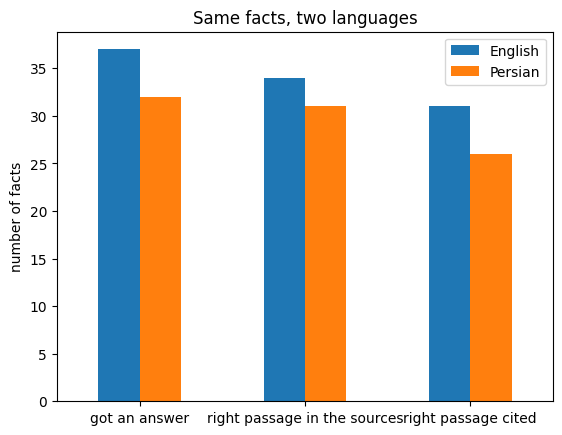

,English,Persian
got an answer,37,32
right passage in the sources,34,31
right passage cited,31,26


In [30]:
check["evidence"] = [item.get("evidence") for item in items]  # same order as the csv
good = check[check["answerable"]].drop_duplicates(["language", "evidence"])
english_side = good[good["language"] == "English"].set_index("evidence")
persian_side = good[good["language"] == "Persian"].set_index("evidence")
same = english_side.index.intersection(persian_side.index)

pairs = pd.DataFrame({
    "English": english_side.loc[same, ["answered", "evidence_in_sources", "evidence_cited"]].sum(),
    "Persian": persian_side.loc[same, ["answered", "evidence_in_sources", "evidence_cited"]].sum(),
})
pairs.index = ["got an answer", "right passage in the sources", "right passage cited"]
print(len(same), "facts asked in both languages")
pairs.plot(kind="bar", rot=0)
plt.ylabel("number of facts")
plt.title("Same facts, two languages")
plt.show()
pairs

Over the 38 facts that were asked in both languages the right passage was cited 31 times in English and 26 times in Persian.
Persian also says "not found" more often for questions the books can answer (32 answers against 37). Six facts worked only in English, one only in Persian.
Refusing a question it could answer is the safer mistake, but it still costs useful answers.

## 15. What it would cost with GPT or Claude
The local model has no price per token. To see what a paid API would cost for the same traffic I take the average tokens per question from the real run and multiply them by the prices in `docs/api_prices.csv`. Those prices come from summary websites on the day I looked (the file says which), so check the official price pages before you decide anything.

In [31]:
prices = pd.read_csv("docs/api_prices.csv")
tokens_in = check["prompt_tokens"].mean()
tokens_out = check["completion_tokens"].mean()
print(f"average per question: {tokens_in:.0f} tokens in, {tokens_out:.0f} tokens out")

prices["USD per 1,000 questions"] = (1000 * tokens_in * prices["usd_per_million_input_tokens"]
                                      + 1000 * tokens_out * prices["usd_per_million_output_tokens"]) / 1e6
prices["USD per 10,000 questions"] = prices["USD per 1,000 questions"] * 10
prices[["model", "USD per 1,000 questions", "USD per 10,000 questions"]].round(2)

average per question: 2051 tokens in, 61 tokens out


,model,"USD per 1,000 questions","USD per 10,000 questions"
0,OpenAI GPT-5 mini,0.64,6.35
1,OpenAI GPT-5,3.18,31.75
2,Claude Haiku 4.5,2.36,23.57
3,Claude Sonnet 5,4.71,47.14


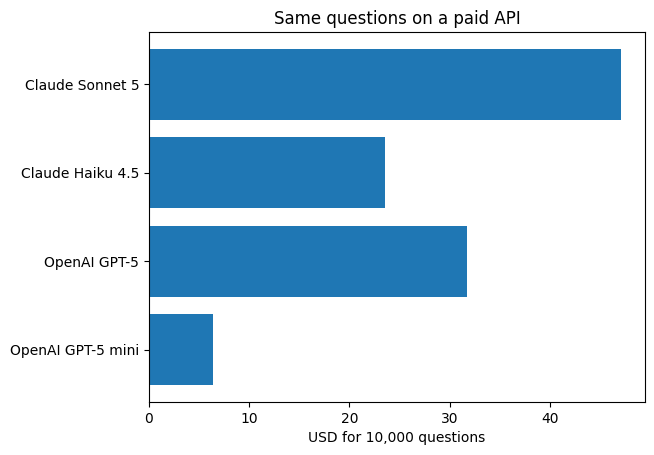

In [32]:
plt.barh(prices["model"], prices["USD per 10,000 questions"])
plt.xlabel("USD for 10,000 questions")
plt.title("Same questions on a paid API")
plt.show()

With about 2,051 tokens in and 61 tokens out per question, 10,000 questions would cost between about USD 6 (GPT-5 mini) and USD 47 (Claude Sonnet 5) on a paid API.
Persian questions need one more small call for the translation, and the judge calls are not counted. The prices come from summary websites and can be out of date.

The local model costs nothing per token, but it needs a GPU server: about 7 hours of one A100 for 10,000 questions. A paid API also answers many users at the same time,
so it is faster when many people ask together. The price of the local setup is speed; the price of the API is that questions leave the hospital network, which this project was built to avoid.

## 16. What happens when the number of users grows?
First the app with the fake LLM (so only the app is tested), from 10 up to 1,000 users at the same moment. Then the real model, where one GPU is the limit.

In [33]:
load = pd.read_csv("docs/load_test_results.csv")
sweep = load[load["test"].str.startswith("fake LLM,")].sort_values("concurrency")
sweep[["test", "users", "answered", "questions_per_second", "median_s", "p95_s"]]

,test,users,answered,questions_per_second,median_s,p95_s
2,"fake LLM, 10 at once",2000,2000,9.5,1.05,1.09
3,"fake LLM, 50 at once",2000,2000,22.2,2.22,2.72
4,"fake LLM, 100 at once",2000,2000,21.5,4.53,5.52
5,"fake LLM, 200 at once",2000,1995,19.8,9.35,17.71
6,"fake LLM, 500 at once",2000,1991,19.4,25.47,32.89
7,"fake LLM, 1000 at once",2000,1999,19.3,49.85,53.80


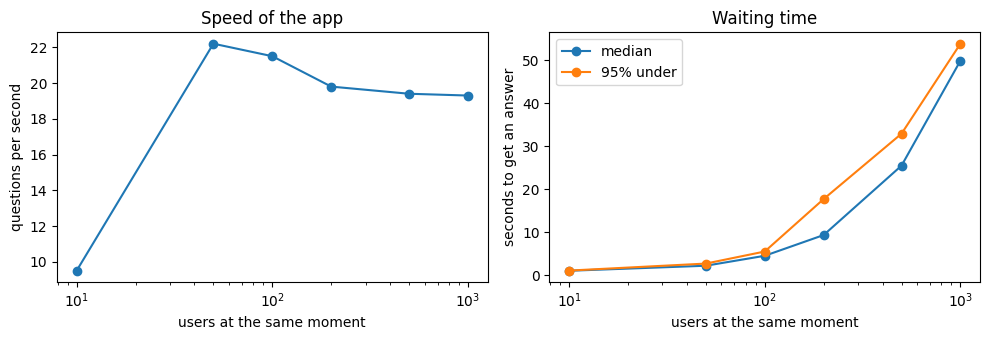

In [34]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.5))
left.plot(sweep["concurrency"], sweep["questions_per_second"], marker="o")
left.set_xscale("log")
left.set_xlabel("users at the same moment")
left.set_ylabel("questions per second")
left.set_title("Speed of the app")
right.plot(sweep["concurrency"], sweep["median_s"], marker="o", label="median")
right.plot(sweep["concurrency"], sweep["p95_s"], marker="o", label="95% under")
right.set_xscale("log")
right.set_xlabel("users at the same moment")
right.set_ylabel("seconds to get an answer")
right.legend()
right.set_title("Waiting time")
plt.tight_layout()
plt.show()

The app does about 20 questions per second. Up to about 50 users at the same moment the wait is just the 1 second of the fake model plus a small queue. After that more users
don't make it faster, they only wait longer: the median wait is roughly the number of users divided by 20 (100 users: 4.5 s, 1,000 users: 50 s).

At 200 users and more, between 1 and 9 requests out of 2,000 (at most 0.5%) were dropped with a `ReadError`, a connection that closed while it was waiting.
The app itself logged no error. My guess is a connection the server closed while the test client was still reusing it, but I did not prove that.
A real service should sit behind nginx or something similar.

### With the real model
One A100 gives about 0.4 answers per second. If many users ask at the same moment they stand in a queue, so the waiting time is roughly **users at the same moment ÷ 0.4** seconds. The dots are the runs I measured, the lines show the same rule for more GPUs (this is a calculation, I only had one GPU for this).

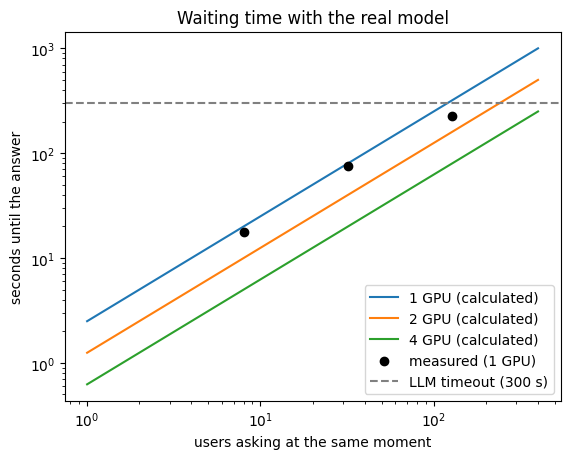

,test,users,concurrency,answered,questions_per_second,median_s,p95_s
1,real model (qwen2.5:32b),400,8,400,0.4,17.83,31.58
8,"real model (qwen2.5:32b), 32 at once",128,32,128,0.4,75.15,91.34
9,"real model (qwen2.5:32b), 128 at once",256,128,256,0.4,225.82,442.25


In [35]:
speed_one_gpu = 0.4
users_now = np.array([1, 2, 5, 10, 20, 50, 100, 200, 400])
for gpus in (1, 2, 4):
    plt.plot(users_now, users_now / (speed_one_gpu * gpus), label=f"{gpus} GPU (calculated)")
real = load[load["test"].str.startswith("real model")]
plt.scatter(real["concurrency"], real["median_s"], color="black", zorder=5, label="measured (1 GPU)")
plt.axhline(300, linestyle="--", color="gray", label="LLM timeout (300 s)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("users asking at the same moment")
plt.ylabel("seconds until the answer")
plt.title("Waiting time with the real model")
plt.legend()
plt.show()
real[["test", "users", "concurrency", "answered", "questions_per_second", "median_s", "p95_s"]]

The real runs follow the rule: 8 users at once wait 18 s, 32 users wait 75 s (the rule says 80 s), and with 128 users the median wait is 226 s and the slowest waited 442 s.
Everything was answered and nothing failed, but no doctor would wait 7 minutes.

So the question is not how many users the app can hold, it is how many answers per second the GPU can make: about 0.4. If 20 doctors asked at the very same moment,
the median wait would be about 50 s. More GPUs, a smaller model or a faster model server (for example vLLM) would help; the app is not the problem.

## 17. Patient questions
A second test, closer to a real product: 525 questions that patients might ask (`data/eval/patient_questions_english_persian_525.csv`), in English and in Persian. The csv has questions and the web pages they should be answered from, but **no reference answers**, so I can't say "this answer is right". I can measure other things: does it answer or say "I don't know", does it cite the page the dataset names, are the numbers in the sources, and does an LLM judge find the answer backed by the sources.

Q001 to Q500 are 25 diseases times the same 20 question types, so they test topic coverage, not 500 different patients. I downloaded the named pages from MedlinePlus, NHS, WHO, NIMH and NIDDK into a separate knowledge base (25 pages). CDC blocked the download (flu, COVID, stroke) and one NHS page had no text (breast cancer), so those topics have no page. Their questions, and the 50 forum-style questions, are the "open" questions: the right answer for most of them is "I don't know".

In [36]:
def patient_answers(name):
    rows = pd.read_csv(f"docs/patient_check_{name}.csv")
    # the app now shows "I don't know" when the model writes NO_ANSWER anywhere, so I count it like that too
    rows["answered"] = rows["answered"] & ~rows["answer"].str.contains("NO_ANSWER", case=False, na=False)
    return rows

patients = {"English": patient_answers("en"), "Persian": patient_answers("fa")}
broken_letters = "[\u3040-\u30ff\u3400-\u9fff\uac00-\ud7af]"  # Chinese, Japanese, Korean

rows = []
for language, part in patients.items():
    given = part[part["answered"]]
    rows.append({
        "language": language,
        "questions": len(part),
        "answered": len(given),
        "said I don't know": len(part) - len(given),
        "cited the expected page": int(given["evidence_cited"].sum()),
        "number in no source": int((given["made_up_numbers"] > 0).sum()),
        "judge: not backed": int(given["judge_supported"].eq(False).sum()),
        "broken letters": int(given["answer"].str.contains(broken_letters).sum()),
        "median seconds": round(part["seconds"].median(), 1),
    })
patient_table = pd.DataFrame(rows).set_index("language")
patient_table.T

language,English,Persian
questions,420.0,419.0
answered,287.0,317.0
said I don't know,133.0,102.0
cited the expected page,284.0,310.0
number in no source,0.0,1.0
judge: not backed,27.0,74.0
broken letters,0.0,13.0
median seconds,4.4,6.5


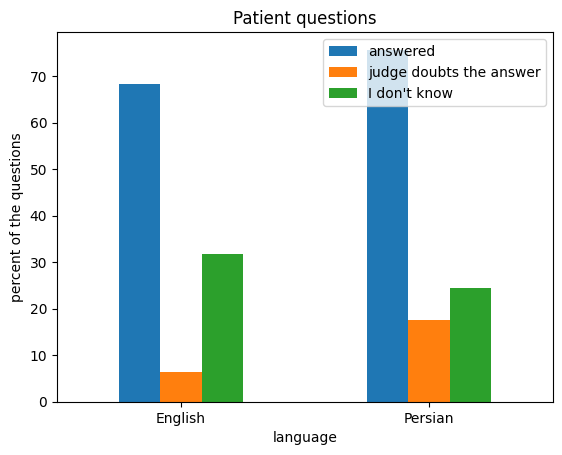

In [37]:
share = pd.DataFrame({
    "answered": patient_table["answered"] / patient_table["questions"],
    "judge doubts the answer": patient_table["judge: not backed"] / patient_table["questions"],
    "I don't know": patient_table["said I don't know"] / patient_table["questions"],
}) * 100
share.plot(kind="bar", rot=0)
plt.ylabel("percent of the questions")
plt.title("Patient questions")
plt.show()

**English:** 68% answered, 32% "I don't know". When it answers, 99% of the answers cite the page the dataset names, and every answer has a citation. None has a number that is in no source and the judge doubts 9%.

**Persian:** 76% answered, and 98% of the answers cite the expected page. But it is clearly weaker: the judge doubts 23% of the answers, only 1 has a number that is in no source, and **13 answers contain broken letters**
(Chinese, Japanese or Korean). One question made the model server fail and is missing (419 of 420). The app now hides the 13 broken answers behind "I don't know".
The judge is the same model that wrote the answers and it reads Persian worse than English, so treat the Persian doubts as a warning, not as an exact number.

**Open questions:** 188 of 210 got "I don't know". The 22 answers came from nearby pages (for example the asthma page does talk about flu), so they are grounded, but not an answer to what was asked.

### Which kinds of question get "I don't know"?

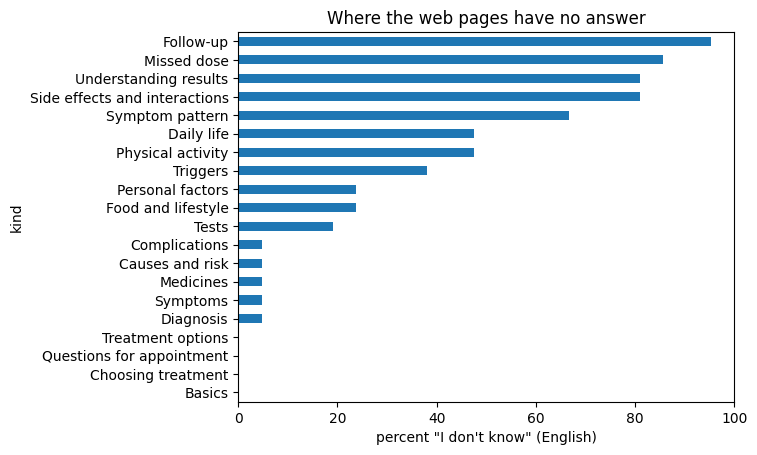

In [38]:
import json

plan = pd.read_csv("data/eval/patient_questions_english_persian_525.csv")
kind = dict(zip(plan["Question ID"], plan["Question intent"]))
ids = [json.loads(line)["id"] for line in open("data/eval/patient_questions_en.jsonl", encoding="utf-8")]
english = patients["English"]
english = english.assign(kind=[kind[i] for i in ids])
unknown = (1 - english.groupby("kind")["answered"].mean()).sort_values() * 100
unknown.plot(kind="barh")
plt.xlabel("percent \"I don't know\" (English)")
plt.title("Where the web pages have no answer")
plt.show()

The web pages explain a disease well, but they say little about how often to come back for follow-up (95% "I don't know"), what to do after a missed dose (86%)
or how to ask a doctor about a test result (81%). For those questions the honest answer is "I don't know", which is correct but makes the product feel thin.
A real product needs pages (or a text written by a doctor) for them.

In [39]:
open_questions = patient_answers("open")
print(len(open_questions), "open questions:", int((~open_questions["answered"]).sum()), "got \"I don't know\",",
      int(open_questions["answered"].sum()), "got an answer")

210 open questions: 188 got "I don't know", 22 got an answer


## 18. Where does the time go?
`python -m scripts.time_steps` runs a question step by step and times each step (30 English and 30 Persian questions, one at a time, results in `docs/time_steps.csv`). The model server (Ollama) also tells how long it needed to read the sources and to write the answer.

In [40]:
steps = pd.read_csv("docs/time_steps.csv")
medians = steps.groupby("language").median(numeric_only=True)
medians["total"] = medians.sum(axis=1)
medians.T.round(1)

language,English,Persian
translate,0.0,913.2
embed question,11.4,11.2
dense search,0.5,0.4
BM25 search,16.2,21.0
merge,0.0,0.0
build prompt,0.1,0.1
LLM: load model,3.4,3.3
LLM: read the sources,1542.4,1578.2
LLM: write the answer,1365.4,1489.6
total,2939.4,4017.0


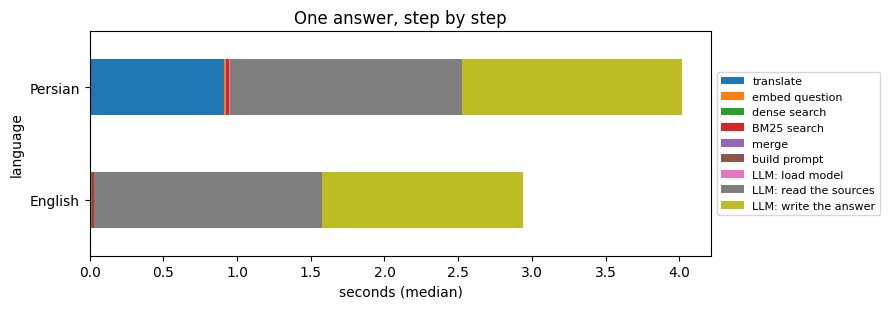

In [41]:
parts = medians.drop(columns="total") / 1000
parts.plot(kind="barh", stacked=True, figsize=(9, 3.2))
plt.xlabel("seconds (median)")
plt.title("One answer, step by step")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [42]:
share_of_time = (100 * medians.drop(columns="total").div(medians["total"], axis=0)).round(1)
share_of_time.T.sort_values("English", ascending=False).head(4)

language,English,Persian
LLM: read the sources,52.5,39.3
LLM: write the answer,46.5,37.1
BM25 search,0.6,0.5
embed question,0.4,0.3


**What takes the time:** the LLM is almost everything. For an English question reading the sources takes 52% of the time (about 1.5 s) and writing the answer 47% (about 1.4 s).
Searching (embedding the question, dense search, BM25, merging) takes about 28 milliseconds, less than 1%. A Persian question also needs a translation call, which is another 0.9 s (23% of its 4.0 s).

**What to optimize:**
1. **Reading the sources:** every question sends 5 chunks (about 2,000 tokens) and this part grows with them. Sending 3 chunks would cut it by about 40% (my estimate, I did not measure it), but the right passage is then found less often (86% in the top 5 against 72% in the top 3), so I did not change it.
2. **Writing the answer:** a faster or smaller model, a faster model server such as vLLM, or a shorter answer limit.
3. **Translation of Persian questions:** a small translation model, or a cache for repeated questions.
4. The search is **not** worth optimizing.

(The steps add up to 2.9 s and 4.0 s, which matches the medians of the answer check. An earlier run showed 2.8 s for writing the answer because the GPU was busy; this run was taken with the GPU idle.)

## 19. What I added to make it safer
The patient test found problems, and I fixed the ones that could be fixed with a few lines:
- **"NO_ANSWER" shown to the user.** In 10 English answers the model explained first and wrote the word NO_ANSWER at the end, and the app only looked at the start of the reply. Now a reply that contains it anywhere becomes the "I don't know" message.
- **Emergency line.** If the question has an urgent word (chest pain, trouble breathing, heavy bleeding, suicide ...), the answer starts with a line that tells the person to call the emergency number (115 in Iran). The word list is short and simple on purpose, a clinician should review it. Every answer also says "in an emergency call your local emergency number" in the disclaimer.
- **Broken Persian.** If an answer to a Persian question has Chinese, Japanese or Korean letters in it, the app shows "I don't know" instead of broken text.
- **Alerts** (`docs/alerts.yml`): app down, errors on the rise, slow answers, too many "not found".
- **A sheet for doctors** (`python -m scripts.review_sample`): 100 answers with empty columns for "correct?" and "safe for a patient?".

In [43]:
from app.rag import looks_urgent

for question in ["I have chest pain, what should I do?", "درد قفسه سینه دارم", "How is COPD diagnosed?"]:
    print(looks_urgent(question), "|", question)

True | I have chest pain, what should I do?
True | درد قفسه سینه دارم
False | How is COPD diagnosed?


In [44]:
review = pd.read_csv("docs/doctor_review.csv")
print(len(review), "answers for the doctors,", review["language"].value_counts().to_dict())
review[["id", "language", "question", "source"]].head(3)

100 answers for the doctors, {'en': 50, 'fa': 50}


,id,language,question,source
0,Q079,en,"Could my age, family history, pregnancy, or an...",MedlinePlus Coronary artery disease; WHO Coron...
1,Q382,en,What symptoms are commonly linked to Obesity?,MedlinePlus Obesity
2,Q468,en,How can I ask my clinician to explain an uncle...,MedlinePlus Hay fever


## 20. Is it production ready?
Not yet. The code side is in good shape, the rest needs people.

| Part | State |
|---|---|
| Tests, CI, metrics, dashboard, alerts, backups, restart | done and tested |
| "I don't know" and citations | done: 99% of English and 98% of Persian answers cite the expected page |
| Emergency line, broken-text guard | done, simple word list, needs a clinician's review |
| A doctor reads the answers | **not done**: the sheet is ready, someone has to fill it in |
| Persian quality | **weak**: 23% of the answers are doubted by the judge, 13 had broken letters |
| Missing pages (flu, COVID, stroke, breast cancer) | **not done** (CDC blocks downloads, ask for the text or use another source) |
| Page licences | **not checked**: check every site before real use |
| HTTPS, accounts, privacy policy for patient questions | **not done**: nginx steps are in `docs/DEPLOY.md`, untested |
| Capacity | one GPU makes about 0.4 answers per second: 20 users at the same moment wait about 50 s |
| Medical-device rules | **not checked**, ask a lawyer: health software can be regulated |

## 21. Run the tests

In [45]:
run = subprocess.run([sys.executable, "-m", "pytest", "-q"], capture_output=True, text=True)
print("\n".join(run.stdout.strip().splitlines()[-6:]))
print("exit code:", run.returncode)

........................................................................ [ 61%]
..............................................                           [100%]
118 passed in 3.20s
exit code: 0


## 22. What I take from this
- **Search:** hybrid beats dense alone and BM25 alone (dev hit rate@5 0.613 against 0.547 and 0.467 on the 141 questions). With the larger question set the tuner picks the same setting I already used (250 words, 2:1).
- **English** works: the right passage is in the top 5 for 86% of the questions (MRR 0.64) and was cited in 46 of 58 answers.
- **Persian** needs the translation step: searched as typed only 15 of 49 are found, with translation 40 of 49 reach the LLM and 34 are cited. It refuses 8 answerable questions and made up 2 answers (eczema, snake bite), with broken words in some answers.
- **Hallucination:** no number outside the sources, no fake citation, and the judge accepted all 100 answers. Still, 2 of 34 unanswerable questions got an answer, so the share of answered unanswerable questions is the number to watch.
- **Speed:** search takes about 21 ms, a whole answer about 3 s. Nearly all of it is the LLM.
- **Cost:** 10,000 questions on a paid API would cost about USD 6 to 47. The local model has no token price, but needs a GPU (about 7 hours of one A100 for 10,000 questions).
- **More users:** the app itself handles about 20 questions per second. The real limit is the GPU, about 0.4 answers per second, so the waiting time is about the number of users divided by 0.4.
- **Caution:** I wrote all 141 questions myself, from the book sentences, which makes exact-word search look better than it would with real doctors' questions. The test split is small, and the paid-API prices are from summary websites.
- **Patient questions:** 68% (English) and 76% (Persian) get an answer that cites the right page, the rest get an honest "I don't know". Persian is weaker (the judge doubts 23% against 9%), and 13 Persian answers had broken letters.
- **The time** goes to the LLM (about 3 s of writing and 1.6 s of reading), not to the search (36 ms). Faster answers need a faster model or server, not a faster search.
- **Safety:** I fixed a "NO_ANSWER" that leaked into answers and added an emergency line, a broken-text guard, alerts and a doctor review sheet. It is a good pilot, not a finished product: a doctor still has to read the answers.